# Tanzania Water Wells 
### First Model Classification

**Author:** Angela Masaki

**Date:** 01/05/2026 - 05/05/2026

----

## Purpose of This Notebook

This notebook builds and evaluates our first three models:
1. **Baseline — Dummy Classifier** (most frequent class prediction)
2. **Model 1 — Logistic Regression** (linear classifier; requires scaling)
3. **Model 2 — Decision Tree Classifier** (non-linear; no scaling needed)

Together, these models provide a progression from simple baseline to more flexible learning approaches. 

Data is loaded from processed CSVs created in `01_EDA.ipynb`.  

----


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    recall_score
)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

## 2. Load Processed Data 

In [2]:
X_train = pd.read_csv('../Data/processed/X_train.csv', index_col='id')
X_val   = pd.read_csv('../Data/processed/X_val.csv',   index_col='id')
X_test  = pd.read_csv('../Data/processed/X_test.csv',  index_col='id')
y_train = pd.read_csv('../Data/processed/y_train.csv', index_col='id').squeeze()
y_val   = pd.read_csv('../Data/processed/y_val.csv',   index_col='id').squeeze()
y_test  = pd.read_csv('../Data/processed/y_test.csv',  index_col='id').squeeze()

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Train: (35640, 25) | Val: (11880, 25) | Test: (11880, 25)


## 3. Evaluation Helper

This function is defied to present results consistently across all the models on this notebook. 

In [3]:
def evaluate_model(model, X_val, y_val, model_name='Model'):
    y_pred = model.predict(X_val)
    
    acc = accuracy_score(y_val, y_pred)
    mac_recall = recall_score(y_val, y_pred, average='macro')

    print(f'=== {model_name} ===')
    print(f'Accuracy:     {acc:.4f}')
    print(f'Macro Recall: {mac_recall:.4f}')
    print()
    print(classification_report(y_val, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=12)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    return y_pred, {'accuracy': acc, 'macro_recall': mac_recall}

----

## 4. Classification Models 

## 4.1 Baseline - Dummy Classifier

Before building more coplex models, we establish a baseline using a Dummy Classifier that always predicts the most frequent class (functional). This provides a minimum performance benchmark that reflects the dataset's class distribution. Any subsequent model must outperform this baseline to demonstrate that iyt is learing real patterns rather than simply exploting xlass imbalance. 

=== Dummy Classifier (Baseline) ===
Accuracy:     0.5431
Macro Recall: 0.3333

                         precision    recall  f1-score   support

             functional       0.54      1.00      0.70      6452
functional needs repair       0.00      0.00      0.00       863
         non functional       0.00      0.00      0.00      4565

               accuracy                           0.54     11880
              macro avg       0.18      0.33      0.23     11880
           weighted avg       0.29      0.54      0.38     11880



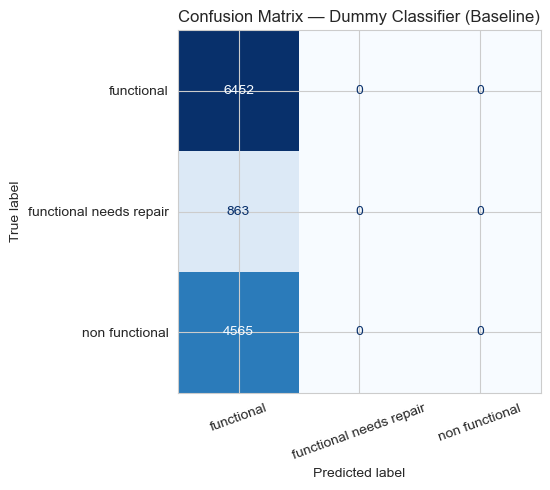

In [4]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

y_pred_dummy, metrics_dummy = evaluate_model(dummy, X_val, y_val, 'Dummy Classifier (Baseline)')

The dummy classifier achieves approximately 54% accuracy by always predicting `functional`. Its recall for `non functional` and `functional needs repair` is 0. The models suggested should beat this.

----------

## 4.2 Model 1 - Logistic Regression

It is a strong linear baseline for classification as it:

- It tests whether the classes are **linearly separable** in feature space
- Its coefficients show the **direction and magnitude** of each feature's effect on the prediction
- If it performs well, it suggests the problem has a linear structure; if it underperforms the Decision Tree, it suggests non-linear relationships are important
- It is fast, well-understood, and commonly used as a reference point in classification pipelines

**Note:** Logistic Regression requires feature scaling. We apply `StandardScaler` here — fit on training data only.

### 4.2.1 Scale Features

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

print('Scaling complete. Train mean (should be ~0):', X_train_scaled.mean().round(4))
print('Train std  (should be ~1):', X_train_scaled.std().round(4))

Scaling complete. Train mean (should be ~0): -0.0
Train std  (should be ~1): 1.0


### 4.2.2 Fit Logistic Regression

=== Logistic Regression ===
Accuracy:     0.6481
Macro Recall: 0.4510

                         precision    recall  f1-score   support

             functional       0.65      0.83      0.73      6452
functional needs repair       0.44      0.01      0.02       863
         non functional       0.64      0.52      0.57      4565

               accuracy                           0.65     11880
              macro avg       0.58      0.45      0.44     11880
           weighted avg       0.63      0.65      0.62     11880



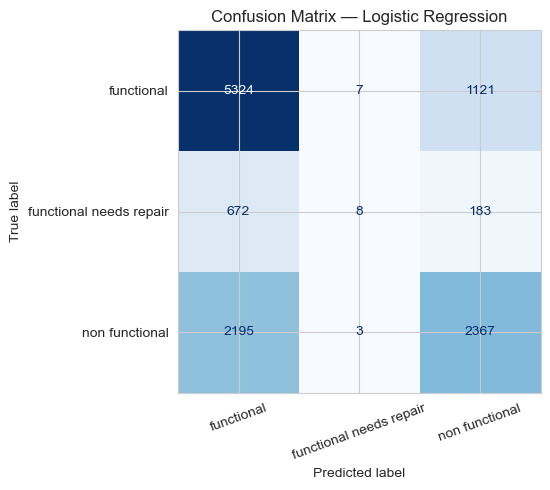

In [6]:
# Logistic Regression
lr = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)

y_pred_lr, metrics_lr = evaluate_model(lr, X_val_scaled, y_val, 'Logistic Regression')

### 4.3 Cross Validation - Logistic Regression

In [7]:
cv_lr = cross_val_score(
    LogisticRegression(multi_class='multinomial', solver='lbfgs',
                       max_iter=1000, random_state=42),
    X_train_scaled, y_train,
    cv=5, scoring='accuracy'
)

print('Cross-Validation Accuracy — Logistic Regression (5-fold):')
print(f'  Scores: {cv_lr.round(4)}')
print(f'  Mean:   {cv_lr.mean():.4f}')
print(f'  Std:    {cv_lr.std():.4f}')

Cross-Validation Accuracy — Logistic Regression (5-fold):
  Scores: [0.6532 0.6529 0.6514 0.642  0.6389]
  Mean:   0.6477
  Std:    0.0060


Logistic Regression outperforms the baseline, indicating that the features contain meaningful predictive signal. 

However, we have to cross validate with decision tress.

-------

## 4.3 Model 2 - Decision Tree Classifier

Logistic Regression is a linear model hence can oly dra straight decision boundaries. If the well functionality depends on complex interactions between the features, a linear model will miss those patterns. 

Decision Trees capture non-linear relationships and feature interactions with no scaling required. 

For this project I started with max_depth=5 to avoid overfitting then explore depth tradeoffs. 

### 4.3.1 Initial Decision Tree(max_depth=5)

=== Decision Tree (max_depth=5) ===
Accuracy:     0.7172
Macro Recall: 0.5026

                         precision    recall  f1-score   support

             functional       0.68      0.94      0.79      6452
functional needs repair       0.46      0.04      0.07       863
         non functional       0.84      0.53      0.65      4565

               accuracy                           0.72     11880
              macro avg       0.66      0.50      0.50     11880
           weighted avg       0.72      0.72      0.68     11880



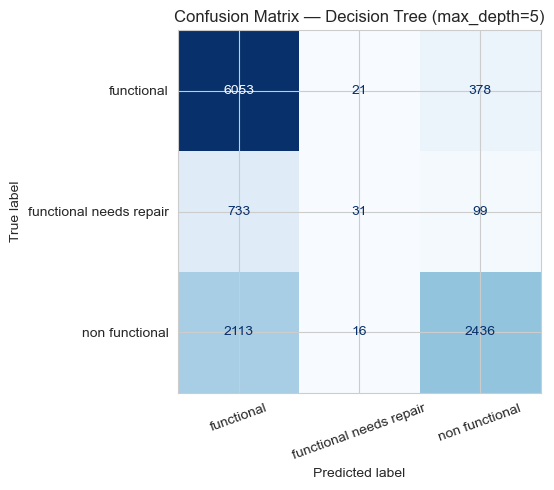

In [8]:
dt_shallow = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_shallow.fit(X_train, y_train)

y_pred_dt5, metrics_dt5 = evaluate_model(dt_shallow, X_val, y_val, 'Decision Tree (max_depth=5)')

### 4.3.2 Tree Visualization

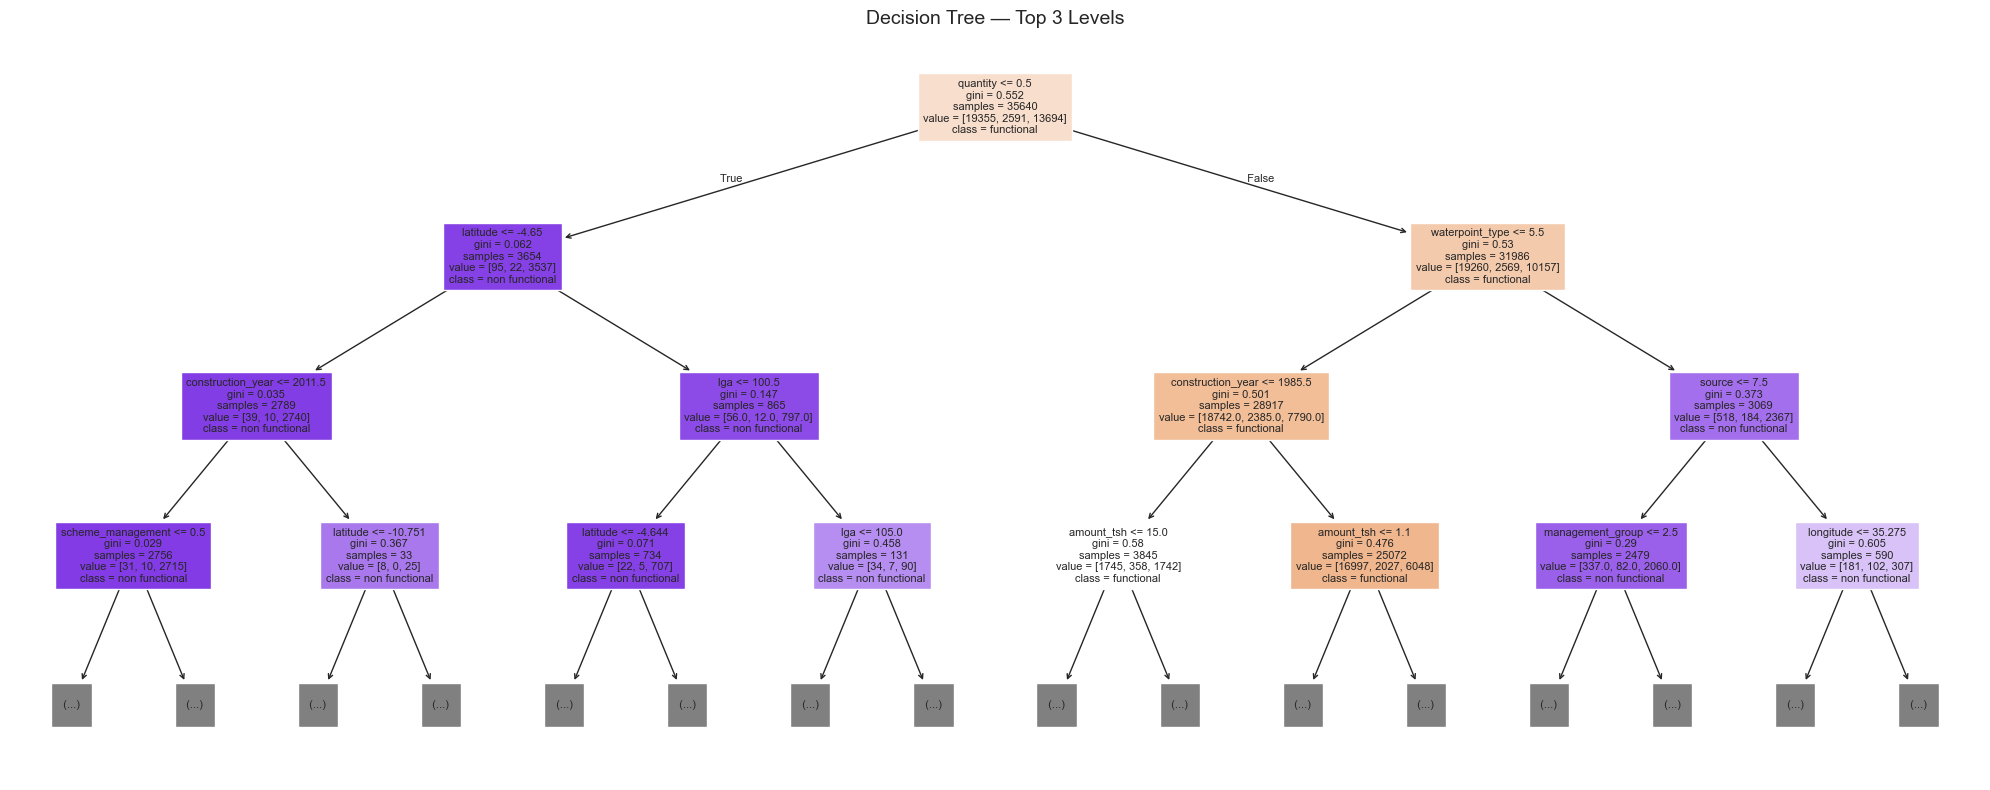

In [9]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_shallow,
    feature_names=X_train.columns,
    class_names=dt_shallow.classes_,
    filled=True,
    max_depth=3,  # Show top 3 levels for readability
    fontsize=8,
    ax=ax
)
ax.set_title('Decision Tree — Top 3 Levels', fontsize=14)
plt.tight_layout()
plt.show()

### 4.3.3 Exploring Tree Depth — Overfitting Check

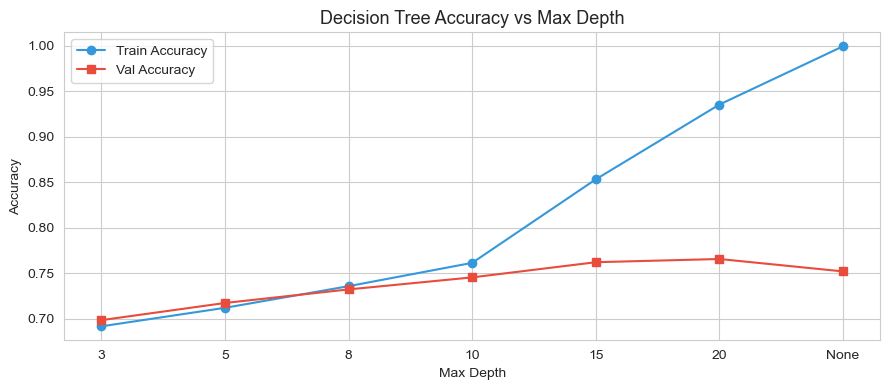

Best max_depth by val accuracy: 20 (0.7655)


In [10]:
depths = [3, 5, 8, 10, 15, 20, None]
train_scores, val_scores = [], []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
    val_scores.append(accuracy_score(y_val, dt.predict(X_val)))

depth_labels = [str(d) if d is not None else 'None' for d in depths]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(depth_labels, train_scores, 'o-', label='Train Accuracy', color='#3498db')
ax.plot(depth_labels, val_scores,   's-', label='Val Accuracy',   color='#e74c3c')
ax.set_title('Decision Tree Accuracy vs Max Depth', fontsize=13)
ax.set_xlabel('Max Depth')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

# Print best validation depth
best_idx = val_scores.index(max(val_scores))
print(f'Best max_depth by val accuracy: {depth_labels[best_idx]} ({val_scores[best_idx]:.4f})')

### 4.3.4 Best Decision Tree

=== Decision Tree (max_depth=20) ===
Accuracy:     0.7655
Macro Recall: 0.6376

                         precision    recall  f1-score   support

             functional       0.79      0.84      0.81      6452
functional needs repair       0.41      0.33      0.37       863
         non functional       0.78      0.74      0.76      4565

               accuracy                           0.77     11880
              macro avg       0.66      0.64      0.65     11880
           weighted avg       0.76      0.77      0.76     11880



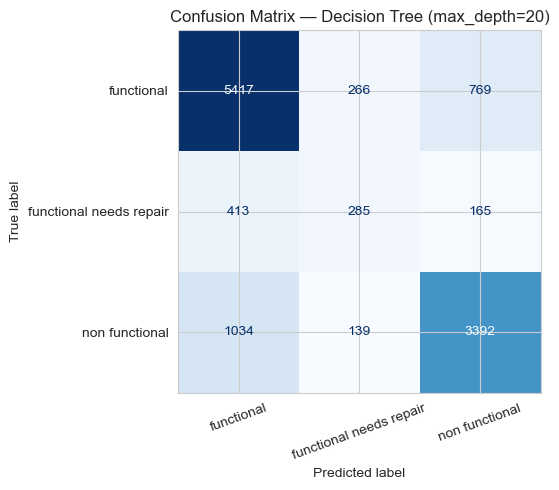

In [11]:
# Use the depth that gave best validation accuracy above
best_depth = depths[best_idx]

dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_best.fit(X_train, y_train)

y_pred_dt_best, metrics_dt_best = evaluate_model(
    dt_best, X_val, y_val, f'Decision Tree (max_depth={best_depth})'
)

### 4.3.5 Feature Importances

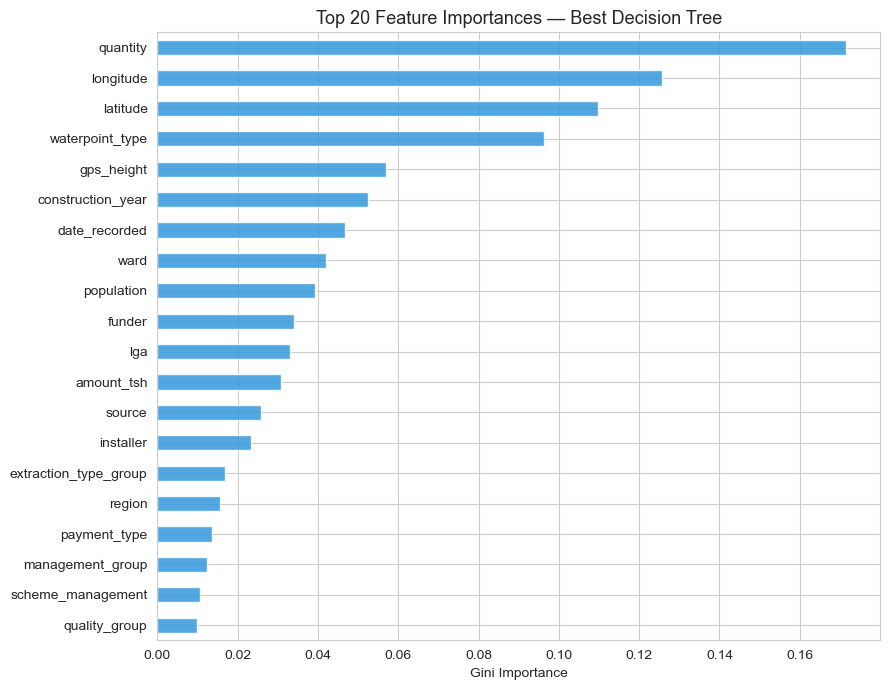

Top 10 features:
quantity             0.171405
longitude            0.125750
latitude             0.109634
waterpoint_type      0.096316
gps_height           0.056939
construction_year    0.052381
date_recorded        0.046644
ward                 0.041991
population           0.039248
funder               0.034078
dtype: float64


In [12]:
feat_imp = pd.Series(dt_best.feature_importances_, index=X_train.columns)
top_features = feat_imp.nlargest(20)

fig, ax = plt.subplots(figsize=(9, 7))
top_features.sort_values().plot(kind='barh', ax=ax, color='#3498db', alpha=0.85)
ax.set_title('Top 20 Feature Importances — Best Decision Tree', fontsize=13)
ax.set_xlabel('Gini Importance')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(top_features.head(10))

### 4.3.6 Cross-Validation

In [13]:
# 5-fold CV on train set to check stability
cv_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=best_depth, random_state=42),
    X_train, y_train,
    cv=5, scoring='accuracy'
)

print(f'Cross-Validation Accuracy (5-fold):')
print(f'  Scores: {cv_scores.round(4)}')
print(f'  Mean:   {cv_scores.mean():.4f}')
print(f'  Std:    {cv_scores.std():.4f}')

Cross-Validation Accuracy (5-fold):
  Scores: [0.7625 0.7577 0.7511 0.7524 0.7518]
  Mean:   0.7551
  Std:    0.0044


------

## 5. Model Comparison

                                  accuracy  macro_recall
Model                                                   
Dummy Classifier (Baseline)         0.5431        0.3333
Logistic Regression                 0.6481        0.4510
Decision Tree (shallow, depth=5)    0.7172        0.5026
Decision Tree (best depth=20)       0.7655        0.6376


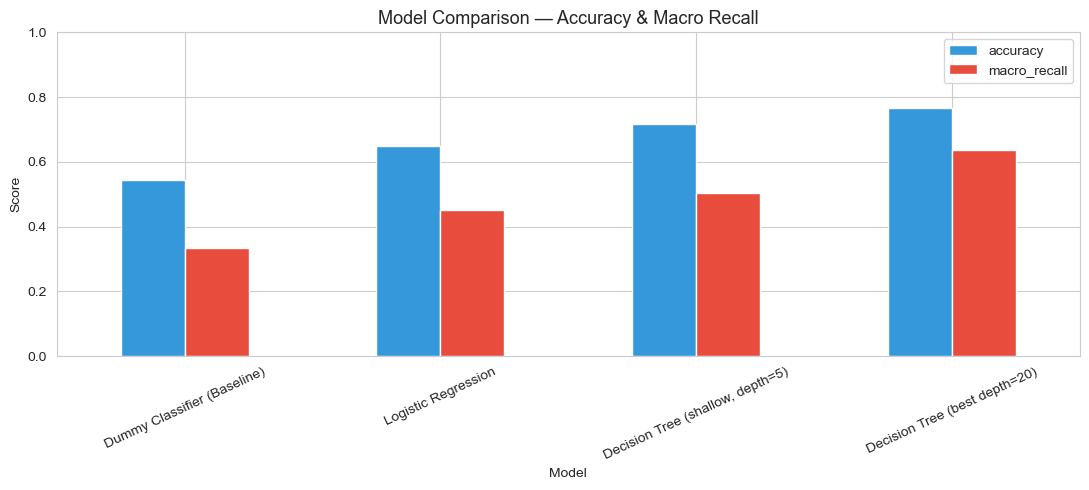

In [14]:
results = pd.DataFrame([
    {'Model': 'Dummy Classifier (Baseline)',              **metrics_dummy},
    {'Model': 'Logistic Regression',                      **metrics_lr},
    {'Model': 'Decision Tree (shallow, depth=5)',         **metrics_dt5},
    {'Model': f'Decision Tree (best depth={best_depth})', **metrics_dt_best},
]).set_index('Model')

print(results.round(4))

# Bar chart
fig, ax = plt.subplots(figsize=(11, 5))
results.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'], edgecolor='white')
ax.set_title('Model Comparison — Accuracy & Macro Recall', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=25)
ax.legend()
plt.tight_layout()
plt.show()

-----

## 6. Interpretation & Business Implications

### Summary of Model Performance

The Decision Tree model demonstrates solid performance in identifying functional and non-functional wells, significantly outperforming the baseline. In particular, it achieves strong recall for non-functional wells (≈77%), indicating that the model is effective at detecting a majority of broken water points.

However, performance is uneven across classes, with the model struggling to accurately classify wells labeled as functional needs repair, reflecting the complexity and ambiguity of this intermediate category.

### Key Business Insights

- **Reliable detection of broken wells:** The model successfully identifies most non-functional wells, making it a useful tool for prioritizing urgent repairs.
- **Risk of missed failures:** A notable number of non-functional wells are misclassified as functional, which could lead to delayed maintenance and continued reliance on unsafe water sources.
- **Uncertainty in borderline cases:** The functional needs repair class is frequently confused with both functional and non-functional wells, limiting confidence in predictions for this group.

### Operational Implications

1. **Prioritize high-confidence failures:** Wells predicted as non-functional should be targeted first for maintenance and inspection.
2. **Introduce secondary checks for borderline wells:** Wells predicted as functional but close to decision boundaries (or historically unstable) should be reviewed, especially to reduce false negatives.
3. **Improve data collection for ambiguous cases:** Additional data or clearer labeling criteria for needs repair wells could significantly improve model performance.

-----

# 7. Conclusion

### Summary

In this project, I developed a multi-class classification model to predict the operational status of water wells across Tanzania. Starting with a baseline Dummy Classifier, I established a minimum performance benchmark and then built two models: Logistic Regression and a Decision Tree Classifier.

The Decision Tree outperformed the linear model, indicating that non-linear relationships and feature interactions play a significant role in determining well functionality. This makes it a more suitable approach for capturing the complexity of the dataset.

### Recommendations for the Ministry of Water
1. **Use the model for early detection:** Apply the Decision Tree to identify likely non-functional wells and prioritize them for inspection and repair.
2. **Focus on high-risk predictions:** Wells predicted as non-functional should be treated as urgent cases, especially given the cost of missed failures.
3. **Monitor borderline wells:** Wells classified as functional needs repair should be flagged for routine inspection, as the model shows difficulty distinguishing this class.


### Limitations
- **Class imbalance:** The functional needs repair category is underrepresented and frequently misclassified, reducing model reliability for this group.
- **Model simplicity:** While the Decision Tree captures non-linear patterns, it may overfit and lacks the robustness of ensemble methods.
- **Data quality issues:** Missing or inconsistent values (e.g., funder, installer, construction year) limit predictive performance.

### Next Steps
- Experiment with ensemble models like Random Forest or gradient boosting to improve performance and generalization
- Apply class weighting or resampling techniques to improve recall for minority classes
- Continuously retrain the model with updated data to reflect real-world changes in well status